# Partition Visualization

Visualize graph partitions on the spatial mesh.

# Visualize Graph Partitioning with METIS

This notebook loads the static graph structure from the provided data files, partitions the graph using METIS (as done in the Cluster-GCN preprocessing step), and visualizes the resulting clusters.

In [1]:
import os
import sys
import numpy as np
import torch
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Add parent directory to path
sys.path.insert(0, os.getcwd())

from utils.file_utils import read_yaml_file
from utils.cluster_utils import load_base_graph_structure, partition_graph
from data import FloodEventDataset
from data.boundary_condition import BoundaryCondition

/Users/lincoln/Documents/UROP/flood_pi_gnn-1/venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


## Configuration

Set up paths and parameters for partitioning visualization.

In [2]:
# Configuration
config = read_yaml_file('configs/config.yaml')
dataset_parameters = config['dataset_parameters']
root_dir = dataset_parameters['root_dir']
raw_dir = os.path.join(root_dir, 'raw')

# Partition parameters
NUM_CLUSTERS = 80  # Change this to desired number of partitions

# Get file paths
nodes_shp_file = dataset_parameters['nodes_shp_file']
edges_shp_file = dataset_parameters['edges_shp_file']
mesh_face_path = os.path.join(raw_dir, 'New_Geometry/faces.shp')

# Get a representative HEC-RAS file
training_summary_file = dataset_parameters['training']['dataset_summary_file']
train_summary_path = os.path.join(raw_dir, training_summary_file)
train_summary_df = pd.read_csv(train_summary_path)
hec_ras_geo_file = train_summary_df['HECRAS_Filepath'].iloc[0]

print(f"Configuration loaded:")
print(f"  Raw directory: {raw_dir}")
print(f"  Number of clusters: {NUM_CLUSTERS}")
print(f"  HEC-RAS file for geometry: {hec_ras_geo_file}")

Configuration loaded:
  Raw directory: data/datasets/raw
  Number of clusters: 80
  HEC-RAS file for geometry: HEC-RAS Results/Model_01.p22.hdf


## Load Base Graph Structure

Load the static graph structure and position data.

In [3]:
print("Loading base graph structure...")
base_graph = load_base_graph_structure(raw_dir, nodes_shp_file, edges_shp_file, hec_ras_geo_file)

print(f"Graph loaded:")
print(f"  Nodes: {base_graph.num_nodes}")
print(f"  Edges: {base_graph.num_edges}")
print(f"  Position shape: {base_graph.pos.shape if hasattr(base_graph, 'pos') else 'Not set'}")

Loading base graph structure...
Loading base graph structure using:
  Nodes: data/datasets/raw/New_Geometry/cell_centers_with_ele.shp
  Edges: data/datasets/raw/New_Geometry/links_with_slope.shp
  Geo:   data/datasets/raw/HEC-RAS Results/Model_01.p22.hdf
Loaded base graph structure with 1268 nodes and 2612 edges.
Graph loaded:
  Nodes: 1268
  Edges: 2612
  Position shape: torch.Size([1268, 2])


## Partition Graph

Partition the graph into clusters using METIS.

In [4]:
print(f"Partitioning graph into {NUM_CLUSTERS} clusters...")
partitioned_graph = partition_graph(base_graph, NUM_CLUSTERS)

print(f"Partitioning complete:")
print(f"  Partition array shape: {partitioned_graph.part.shape}")
print(f"  Unique partitions: {partitioned_graph.part.max().item() + 1}")
print(f"  Nodes per partition (avg): {partitioned_graph.part.shape[0] / (partitioned_graph.part.max().item() + 1):.1f}")

Partitioning graph into 80 clusters...
Partitioning graph into 80 clusters...
Partitioning complete:
  Partition array shape: torch.Size([1268])
  Unique partitions: 80
  Nodes per partition (avg): 15.8


## Load Mesh Geometry

Load the mesh faces for visualization (similar to view_results).

In [5]:
print("Loading mesh nodes and faces...")

# Load mesh faces
faces_gdf = gpd.read_file(mesh_face_path)
print(f"Mesh faces loaded: {len(faces_gdf)} polygons")

# Load node centers
nodes_shp_path = os.path.join(raw_dir, nodes_shp_file)
nodes_gdf = gpd.read_file(nodes_shp_path)
print(f"Node centers loaded: {len(nodes_gdf)} nodes")

Loading mesh nodes and faces...
Mesh faces loaded: 2612 polygons
Node centers loaded: 1268 nodes


## Visualize Partitions on Map

Create a map-based visualization of the partitions (similar to view_results style).

In [9]:
def map_nodes_to_faces(faces_gdf, nodes_gdf):
    """Map node centers to mesh faces for visualization."""
    result_gdf = nodes_gdf.copy()
    
    # Store original center coordinates
    result_gdf['center_x'] = nodes_gdf.geometry.x
    result_gdf['center_y'] = nodes_gdf.geometry.y
    
    # Create spatial index for efficient querying
    spatial_index = faces_gdf.sindex
    
    matched_polygons = []
    for idx, center in nodes_gdf.iterrows():
        center_point = center.geometry
        
        # Get candidate polygons using spatial index
        possible_matches_idx = list(spatial_index.intersection(center_point.bounds))
        possible_matches = faces_gdf.iloc[possible_matches_idx]
        
        # Find which polygon actually contains the point
        match_found = False
        for _, poly_row in possible_matches.iterrows():
            if poly_row.contains(center_point):
                matched_polygons.append(poly_row.geometry)
                match_found = True
                break
        
        if not match_found:
            matched_polygons.append(None)
    
    result_gdf['geometry'] = matched_polygons
    
    # Report unmatched
    unmatched = result_gdf[result_gdf['geometry'].isna()]
    if len(unmatched) > 0:
        print(f"Warning: {len(unmatched)} nodes could not be matched to mesh faces")
    
    return result_gdf

# Map nodes to mesh faces
print("Mapping nodes to mesh faces...")
mesh_gdf = map_nodes_to_faces(faces_gdf, nodes_gdf)
print(f"Mesh GeoDataFrame created with {len(mesh_gdf)} polygons")

Mapping nodes to mesh faces...


AttributeError: 'Series' object has no attribute 'contains'

In [ ]:
def plot_partitions(mesh_gdf, partitions, title="Graph Partitions"):
    """Plot partitions on the mesh using color mapping."""
    fig, ax = plt.subplots(figsize=(14, 12))
    
    # Add partition data to GeoDataFrame
    mesh_gdf_plot = mesh_gdf.copy()
    mesh_gdf_plot['partition'] = partitions.cpu().numpy()
    
    # Plot with colormap
    mesh_gdf_plot.plot(
        ax=ax,
        column='partition',
        cmap='tab20c',  # Use a colormap with many distinct colors
        edgecolor='k',
        linewidth=0.2,
        alpha=0.8,
        legend=True
    )
    
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.set_xlabel('X Coordinate (m)')
    ax.set_ylabel('Y Coordinate (m)')
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()

# Plot the partitions
print("Plotting partitions on mesh...")
plot_partitions(mesh_gdf, partitioned_graph.part, 
                title=f"Graph Partitions ({NUM_CLUSTERS} clusters)")

Plotting partitions on mesh...


NameError: name 'mesh_gdf' is not defined

In [13]:
import numpy as np
import pymetis
import networkx as nx
import matplotlib.pyplot as plt

# 1. Load your data (Assuming .npy or similar, adjust based on your actual file format)
# Replace 'path/to/your/file' with your actual directory path
path = "data/datasets/raw/New_Geometry/cell_centers_with_ele.shp" 
data = np.load(path)

pos = data['pos']                # Shape: [num_nodes, 2]
edge_index = data['edge_index']  # Shape: [2, num_edges]

num_nodes = pos.shape[0]
n_clusters = 4  # Change this to your desired number of clusters

# 2. Prepare Adjacency List for PyMetis
# PyMetis expects a list of arrays where adjncy[i] contains neighbors of node i
adj_list = [[] for _ in range(num_nodes)]
for u, v in edge_index.T:
    adj_list[u].append(v)
    adj_list[v].append(u)

# 3. Perform Clustering with PyMetis
# cuts: number of edges cut by the partition
# membership: a list where index i is the cluster ID for node i
cuts, membership = pymetis.part_graph(n_clusters, adjacency=adj_list)

# 4. Visualization
plt.figure(figsize=(10, 8))
G = nx.Graph()
G.add_nodes_from(range(num_nodes))
G.add_edges_from(edge_index.T)

# Convert pos array to dictionary for NetworkX
pos_dict = {i: pos[i] for i in range(num_nodes)}

# Draw nodes colored by their cluster membership
nx.draw_networkx_nodes(G, pos_dict, node_size=50, 
                       node_color=membership, cmap=plt.cm.jet)
nx.draw_networkx_edges(G, pos_dict, alpha=0.3)

plt.title(f"PyMetis Graph Partitioning ({n_clusters} Clusters)")
plt.axis('off')
plt.show()

ValueError: Cannot load file containing pickled data when allow_pickle=False

Please verify the column name for your edge index!


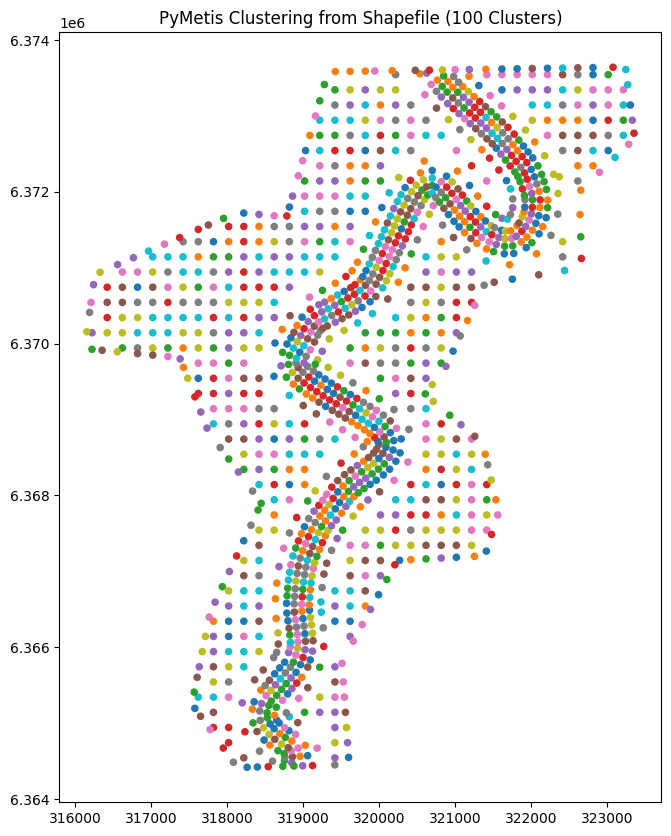

In [16]:
import geopandas as gpd
import numpy as np
import pymetis
import networkx as nx
import matplotlib.pyplot as plt
from shapely.geometry import Point

# 1. Load the Shapefile
# Replace 'path/to/your/file.shp' with your actual path
path = "data/datasets/raw/New_Geometry/cell_centers_with_ele.shp"
gdf = gpd.read_file(path)

# 2. Extract Position and Edge Index
# Assuming 'pos' is the geometry and 'edge_index' is a column in the DBF
# Note: If edge_index is stored as a string like "[0, 1]", we need to parse it.
pos = np.array([[geom.x, geom.y] for geom in gdf.geometry])
num_nodes = len(pos)

# Handling edge_index: Shapefiles usually store attributes per row.
# If your edges are stored in a specific column as a list of neighbors:
adj_list = [[] for _ in range(num_nodes)]

# If your file has an 'edge_index' column that defines connections:
# (Adjust this logic based on how your specific .shp stores edges)
if 'edge_index' in gdf.columns:
    # This assumes edge_index is stored as a tuple/list in each row
    for i, neighbors in enumerate(gdf['edge_index']):
        if isinstance(neighbors, (list, np.ndarray)):
            adj_list[i] = list(neighbors)
else:
    # If the .shp is just nodes, you'd usually generate edges via distance 
    # but since you mentioned edge_index exists, we use it here.
    print("Please verify the column name for your edge index!")

# 3. PyMetis Partitioning (Non-destructive)
n_clusters = 100
cuts, membership = pymetis.part_graph(n_clusters, adjacency=adj_list)

# 4. Create the NEW Clustered Object
# This creates a new graph containing only edges that stay within clusters
G_clustered = nx.Graph()
for i, neighbors in enumerate(adj_list):
    for neighbor in neighbors:
        if membership[i] == membership[neighbor]:
            G_clustered.add_edge(i, neighbor)

# 5. Visualise
fig, ax = plt.subplots(figsize=(10, 10))

# Convert membership to a color array for plotting
gdf['cluster'] = membership

# Plot the original shapes colored by cluster
gdf.plot(column='cluster', ax=ax, cmap='tab10', markersize=20, label='Clusters')

# Overlay the edges for the new graph object
pos_dict = {i: pos[i] for i in range(num_nodes)}
nx.draw_networkx_edges(G_clustered, pos_dict, ax=ax, alpha=0.3, edge_color='black')

plt.title(f"PyMetis Clustering from Shapefile ({n_clusters} Clusters)")
plt.show()

In [17]:
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# 1. Load your Shapefile
path = "data/datasets/raw/New_Geometry/cell_centers_with_ele.shp"
gdf = gpd.read_file(path)

# 2. Extract positions and handle the edge_index
# Assuming geometry is Point data
pos = np.array([[geom.x, geom.y] for geom in gdf.geometry])
pos_dict = {i: pos[i] for i in range(len(pos))}

# Let's assume your edge_index is a list of pairs (u, v)
# If it's stored in a column, we extract it here:
edges = []
for idx, row in gdf.iterrows():
    # Adjust 'edge_index' to whatever your column name is
    neighbors = row['edge_index'] 
    for neighbor in neighbors:
        edges.append((idx, neighbor))

# 3. Create the NetworkX Graph
G = nx.Graph()
G.add_nodes_from(range(len(pos)))
G.add_edges_from(edges)

# 4. Plotting
plt.figure(figsize=(12, 12))

# Draw the Edges first (so they are behind nodes)
nx.draw_networkx_edges(
    G, pos_dict, 
    width=1.0, 
    alpha=0.3, 
    edge_color='gray'
)

# Draw the Nodes
# If you already ran PyMetis, you can set node_color=membership
nx.draw_networkx_nodes(
    G, pos_dict, 
    node_size=30, 
    node_color='skyblue', # Or use your 'membership' list here
    edgecolors='white', 
    linewidths=0.5
)

plt.title("Graph Visualization: Nodes (pos) and Edges (edge_index)")
plt.axis('off') # Hide the lat/long axes for a cleaner look
plt.show()

KeyError: 'edge_index'

In [19]:
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the Shapefile
path = "data/datasets/raw/New_Geometry/cell_centers_with_ele.shp"
gdf = gpd.read_file(path)

# 2. Extract Positions (The 'pos' part)
# We pull (x, y) coordinates from the geometry column
pos = np.array([[geom.x, geom.y] for geom in gdf.geometry])
pos_dict = {i: pos[i] for i in range(len(pos))}

# 3. Extract the Edge Index
# Assuming 'edge_index' is stored as a single object/attribute in your file
# We extract it and convert it to a standard (2, E) or (E, 2) shape
raw_edge_index = gdf['edge_index'] # This pulls the column

# IMPORTANT: If your edge_index is stored as a numpy array inside the .shp
# we need to make sure it's in a list of tuples for NetworkX.
# We'll flatten it if it's nested or just iterate the pairs:
edges = []
for entry in raw_edge_index:
    if isinstance(entry, (list, np.ndarray)):
        # If entry is [neighbor1, neighbor2...], we pair it with the node index
        # This part depends slightly on how your specific .shp was saved
        pass 

# If your edge_index is already a simple list of (u, v) pairs:
edges = np.vstack(raw_edge_index) # Converts to a clean (Total_Edges, 2) array

# 4. Create the Graph Object
G = nx.Graph()
G.add_nodes_from(range(len(pos)))
G.add_edges_from(edges)

# 5. Visualise Nodes and Edges
plt.figure(figsize=(12, 10))

# A. Draw Edges (the connections)
nx.draw_networkx_edges(
    G, pos_dict, 
    width=0.7, 
    alpha=0.4, 
    edge_color='#444444' # Dark grey for visibility
)

# B. Draw Nodes (the points)
nx.draw_networkx_nodes(
    G, pos_dict, 
    node_size=25, 
    node_color='salmon', 
    edgecolors='black', 
    linewidths=0.2
)

plt.title("Visualisation of Graph Nodes and Edges")
plt.axis('equal') # Keeps the aspect ratio from being distorted
plt.axis('off')
plt.show()

KeyError: 'edge_index'

## Simplified Partitioning from Processed Data

Load edge_index from the already-processed constant_values.npz file (no HEC-RAS needed).

In [32]:
import numpy as np
import torch
import pymetis
from torch_geometric.utils import to_undirected
from data.shp_data_retrieval import get_cell_position

# 1. Load edge_index and num_nodes from processed data (fast, no HEC-RAS needed)
constant_values_path = 'data/datasets/processed/constant_values.npz'
constant_values = np.load(constant_values_path)
edge_index = constant_values['edge_index']  # Shape: (2, num_edges)
static_nodes = constant_values['static_nodes']
num_nodes = static_nodes.shape[0]

print(f"Loaded from {constant_values_path}:")
print(f"  Nodes: {num_nodes}")
print(f"  Edges: {edge_index.shape[1]}")

# 2. Load ALL positions from shapefile first
nodes_shp_path = 'data/datasets/raw/New_Geometry/cell_centers_with_ele.shp'
all_pos = get_cell_position(nodes_shp_path)
print(f"  All positions from shapefile: {all_pos.shape}")

# 3. Get boundary info to filter positions (match processed data)
# Load boundary condition data to know which nodes were kept
try:
    boundary_data_path = 'data/datasets/processed/boundary_condition.npz'
    boundary_data = np.load(boundary_data_path)
    kept_nodes_mask = ~boundary_data['boundary_nodes_mask']  # Nodes that weren't removed
    pos = all_pos[kept_nodes_mask]  # Filter to match processed graph
    print(f"  Filtered positions (after boundary removal): {pos.shape}")
except FileNotFoundError:
    print(f"Warning: Could not load boundary_condition.npz")
    print(f"Position mismatch: {all_pos.shape[0]} positions but {num_nodes} nodes in graph")
    # Fallback: just use first num_nodes positions (may not be spatially correct)
    pos = all_pos[:num_nodes]

# 4. Convert to PyMetis format and partition
edge_index_torch = torch.from_numpy(edge_index).long()
edge_index_undirected = to_undirected(edge_index_torch, num_nodes=num_nodes)

# Build adjacency list
adj_list = [[] for _ in range(num_nodes)]
for u, v in edge_index_undirected.t().tolist():
    adj_list[u].append(v)

# Partition
n_clusters = 30
print(f"\nPartitioning into {n_clusters} clusters...")
cuts, membership = pymetis.part_graph(n_clusters, adjacency=adj_list)

print(f"Partitioning complete:")
print(f"  Edge cuts: {cuts}")
print(f"  Unique clusters: {len(set(membership))}")
print(f"  Nodes per cluster (avg): {num_nodes / len(set(membership)):.1f}")

Loaded from data/datasets/processed/constant_values.npz:
  Nodes: 1129
  Edges: 2473
  All positions from shapefile: (1268, 2)
Position mismatch: 1268 positions but 1129 nodes in graph

Partitioning into 200 clusters...
Partitioning complete:
  Edge cuts: 1687
  Unique clusters: 200
  Nodes per cluster (avg): 5.6


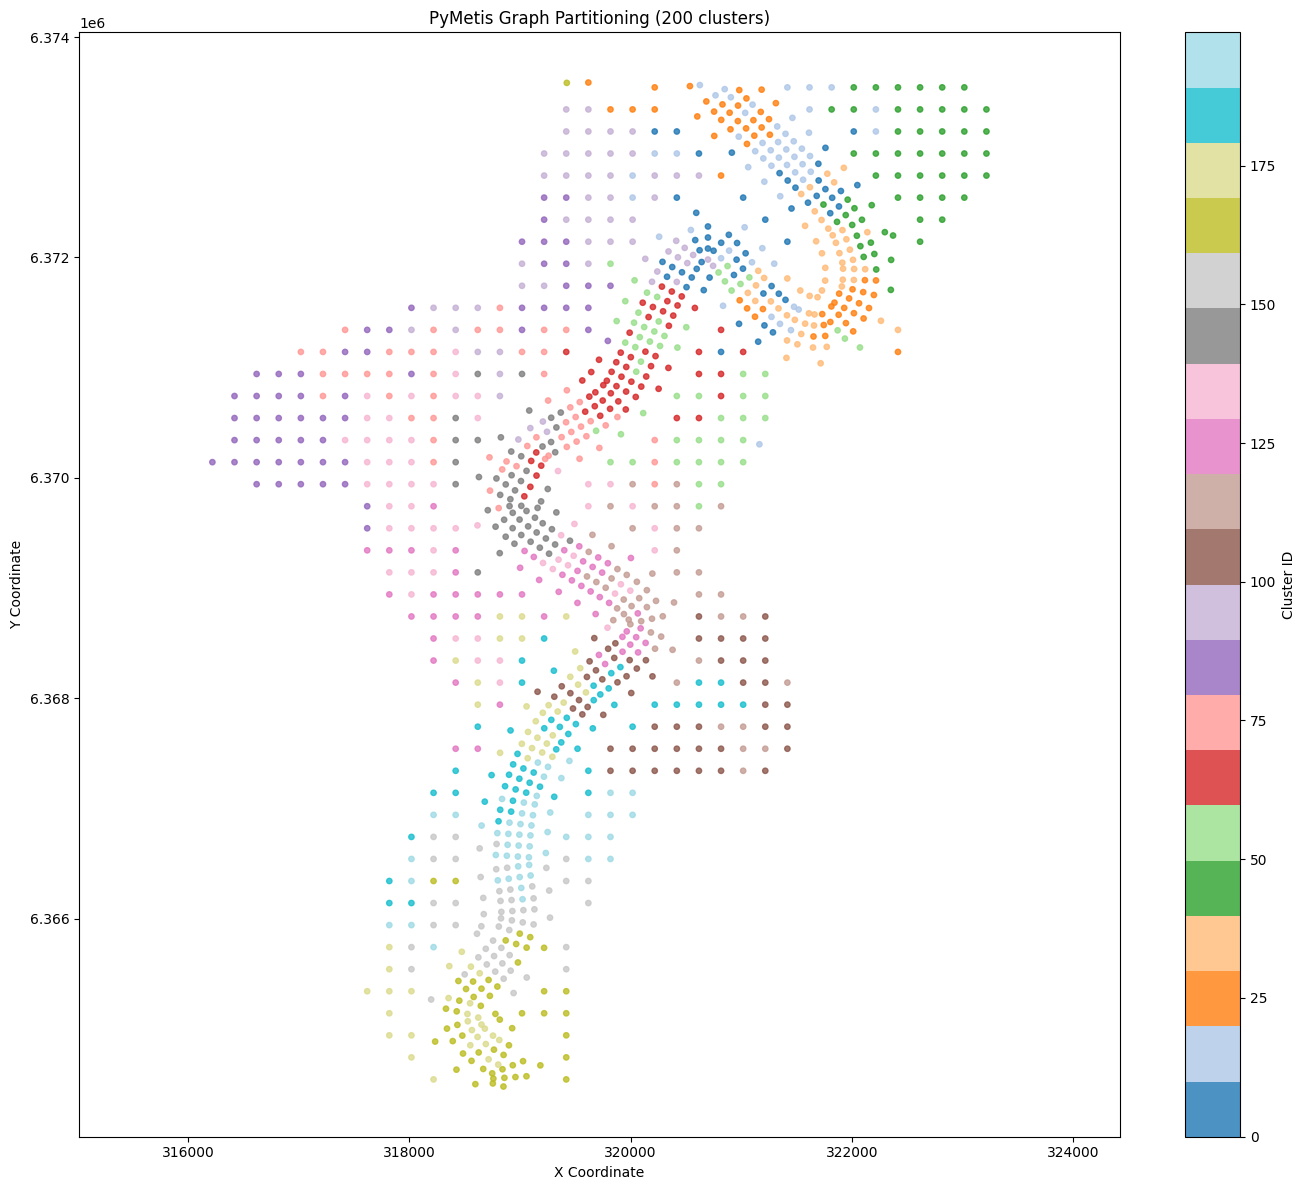

In [33]:
# 4. Visualize the partitions
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 12))
scatter = plt.scatter(pos[:, 0], pos[:, 1], c=membership, cmap='tab20', s=15, alpha=0.8)
plt.colorbar(scatter, label='Cluster ID')
plt.title(f'PyMetis Graph Partitioning ({n_clusters} clusters)')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.axis('equal')
plt.tight_layout()
plt.show()

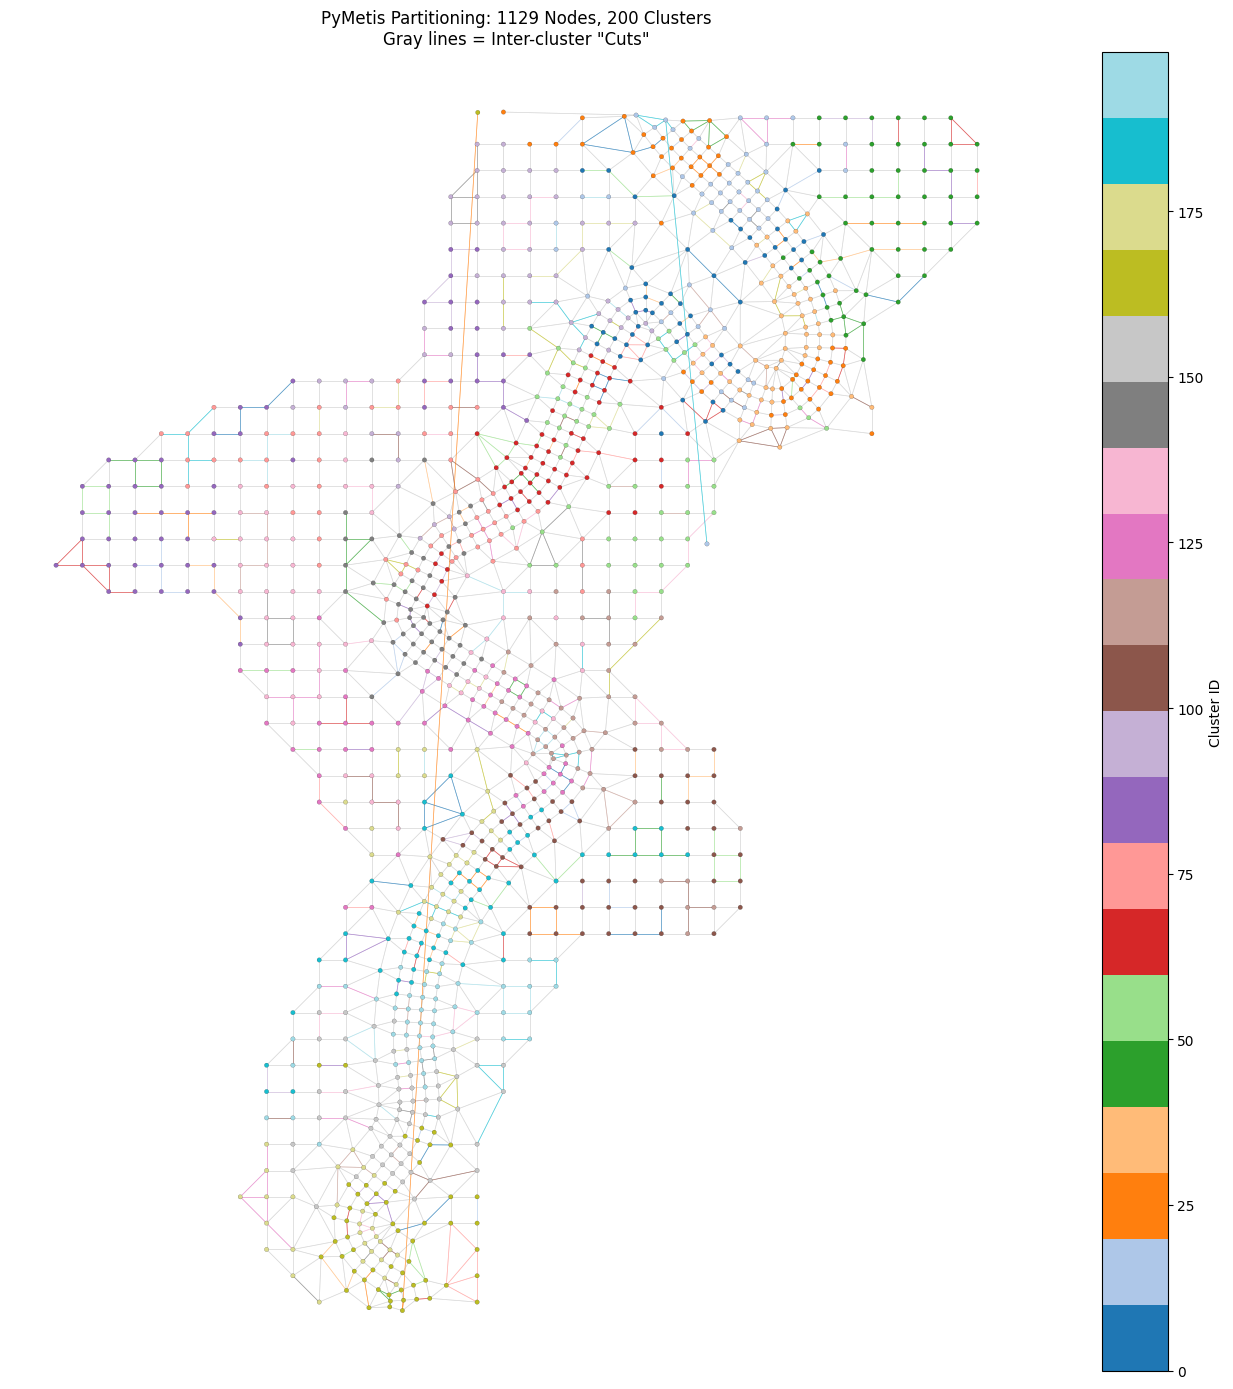

In [27]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

# 1. Prepare Edge Coordinates
# edge_index_undirected is (2, num_edges)
u_idx = edge_index_undirected[0].numpy()
v_idx = edge_index_undirected[1].numpy()

# Get start and end points for every edge
start_points = pos[u_idx]
end_points = pos[v_idx]

# Create a list of lines [[(x1, y1), (x2, y2)], ...]
lines = np.stack([start_points, end_points], axis=1)

# 2. Determine Edge Colors (Optional: Highlight Cuts)
edge_membership_u = np.array(membership)[u_idx]
edge_membership_v = np.array(membership)[v_idx]

# Edges where both nodes are in the same cluster get the cluster color
# Edges that connect different clusters (cuts) will be light gray
is_cut = edge_membership_u != edge_membership_v
line_colors = plt.cm.tab20(edge_membership_u % 20) # Match node colormap
line_colors[is_cut] = [0.8, 0.8, 0.8, 0.1] # Gray and very transparent for cuts

# 3. Final Plot
fig, ax = plt.subplots(figsize=(16, 14))

# Draw Edges first (LineCollection is very fast for large graphs)
lc = LineCollection(lines, colors=line_colors, linewidths=0.5, alpha=0.5)
ax.add_collection(lc)

# Draw Nodes on top
scatter = ax.scatter(
    pos[:, 0], pos[:, 1], 
    c=membership, 
    cmap='tab20', 
    s=10, 
    zorder=3, 
    alpha=1.0, 
    edgecolors='black', 
    linewidths=0.1
)

# Formatting
plt.colorbar(scatter, label='Cluster ID', ax=ax)
ax.set_title(f'PyMetis Partitioning: {num_nodes} Nodes, {n_clusters} Clusters\nGray lines = Inter-cluster "Cuts"')
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_axis_off() # Usually looks cleaner for large graphs
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

In [34]:
import numpy as np
import torch
import pymetis
from torch_geometric.utils import to_undirected
from data.shp_data_retrieval import get_cell_position
from data.hecras_data_retrieval import get_min_cell_elevation

# 1. Load edge_index and num_nodes from processed data (fast, no HEC-RAS needed)
constant_values_path = 'data/datasets/processed/constant_values.npz'
constant_values = np.load(constant_values_path)
edge_index = constant_values['edge_index']  # Shape: (2, num_edges)
static_nodes = constant_values['static_nodes']
num_nodes = static_nodes.shape[0]

print(f"Loaded from {constant_values_path}:")
print(f"  Nodes (with boundary placeholders): {num_nodes}")
print(f"  Edges: {edge_index.shape[1]}")

# 2. Load ALL positions from shapefile first
nodes_shp_path = 'data/datasets/raw/New_Geometry/cell_centers_with_ele.shp'
all_pos = get_cell_position(nodes_shp_path)
print(f"  All positions from shapefile (includes ghosts): {all_pos.shape}")

# 3. Identify ghost nodes (NaN elevation) the same way BoundaryCondition does
hec_ras_path = 'data/datasets/raw/HEC-RAS Results/Model_01.p22.hdf'
min_elevation = get_min_cell_elevation(hec_ras_path)
ghost_nodes = np.where(np.isnan(min_elevation))[0]
non_ghost_mask = ~np.isin(np.arange(all_pos.shape[0]), ghost_nodes)
base_pos = all_pos[non_ghost_mask]
print(f"  Ghost nodes found: {len(ghost_nodes)}")
print(f"  Positions after removing ghosts: {base_pos.shape}")

# 4. Load boundary masks to know which nodes are boundary placeholders
boundary_data_path = 'data/datasets/processed/boundary_condition_masks.npz'
boundary_data = np.load(boundary_data_path)
boundary_nodes_mask = boundary_data['boundary_nodes_mask']  # True for boundary placeholder nodes
non_boundary_mask = ~boundary_nodes_mask

# Validate counts align
if base_pos.shape[0] != non_boundary_mask.sum():
    raise ValueError(f"Non-ghost positions ({base_pos.shape[0]}) do not match non-boundary nodes ({non_boundary_mask.sum()}).")

pos_full = np.zeros((num_nodes, base_pos.shape[1]), dtype=base_pos.dtype)
non_boundary_indices = np.where(non_boundary_mask)[0]
pos_full[non_boundary_indices] = base_pos  # positions for regular nodes

# Build undirected edge_index for neighbor lookup
edge_index_torch = torch.from_numpy(edge_index).long()
edge_index_undirected = to_undirected(edge_index_torch, num_nodes=num_nodes)
edge_index_np = edge_index_undirected.numpy()

# 5. Place boundary nodes near their neighbors
boundary_indices = np.where(boundary_nodes_mask)[0]
centroid = pos_full[non_boundary_indices].mean(axis=0) if non_boundary_indices.size > 0 else np.zeros(2)
for b in boundary_indices:
    neighbor_cols = np.where((edge_index_np[0] == b) | (edge_index_np[1] == b))[0]
    neighbor_nodes = np.unique(np.concatenate([edge_index_np[0, neighbor_cols], edge_index_np[1, neighbor_cols]]))
    neighbor_nodes = neighbor_nodes[neighbor_nodes != b]
    known_neighbors = neighbor_nodes[neighbor_nodes < num_nodes]
    known_neighbors = known_neighbors[non_boundary_mask[known_neighbors]]
    if known_neighbors.size > 0:
        pos_full[b] = pos_full[known_neighbors].mean(axis=0)
    else:
        pos_full[b] = centroid

pos = pos_full
print(f"  Final position array (with boundary placeholders): {pos.shape}")

# 6. Convert to PyMetis format and partition
adj_list = [[] for _ in range(num_nodes)]
for u, v in edge_index_undirected.t().tolist():
    adj_list[u].append(v)

n_clusters = 30
print(f"\nPartitioning into {n_clusters} clusters...")
cuts, membership = pymetis.part_graph(n_clusters, adjacency=adj_list)
membership = np.array(membership)

print(f"Partitioning complete:")
print(f"  Edge cuts: {cuts}")
print(f"  Unique clusters: {len(set(membership))}")
print(f"  Nodes per cluster (avg): {num_nodes / len(set(membership)):.1f}")
print(f"  pos shape: {pos.shape}, membership len: {len(membership)}")

Loaded from data/datasets/processed/constant_values.npz:
  Nodes (with boundary placeholders): 1129
  Edges: 2473
  All positions from shapefile (includes ghosts): (1268, 2)
  Ghost nodes found: 142
  Positions after removing ghosts: (1126, 2)
  Final position array (with boundary placeholders): (1129, 2)

Partitioning into 30 clusters...
Partitioning complete:
  Edge cuts: 421
  Unique clusters: 30
  Nodes per cluster (avg): 37.6
  pos shape: (1129, 2), membership len: 1129


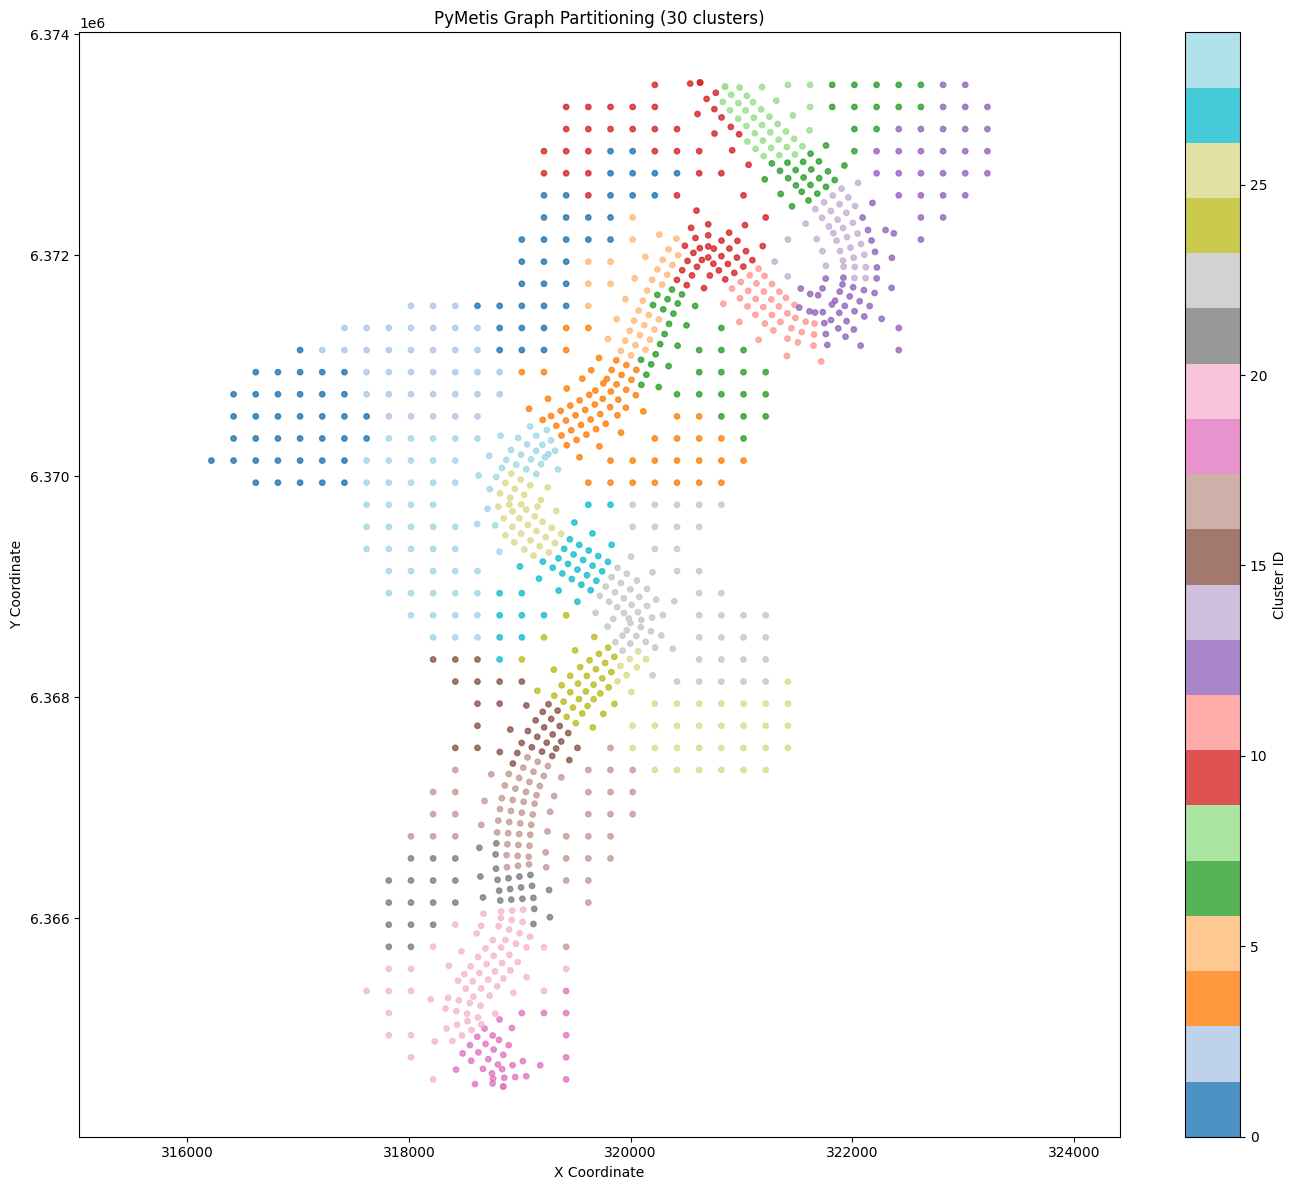

In [35]:
# 4. Visualize the partitions
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 12))
scatter = plt.scatter(pos[:, 0], pos[:, 1], c=membership, cmap='tab20', s=15, alpha=0.8)
plt.colorbar(scatter, label='Cluster ID')
plt.title(f'PyMetis Graph Partitioning ({n_clusters} clusters)')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.axis('equal')
plt.tight_layout()
plt.show()

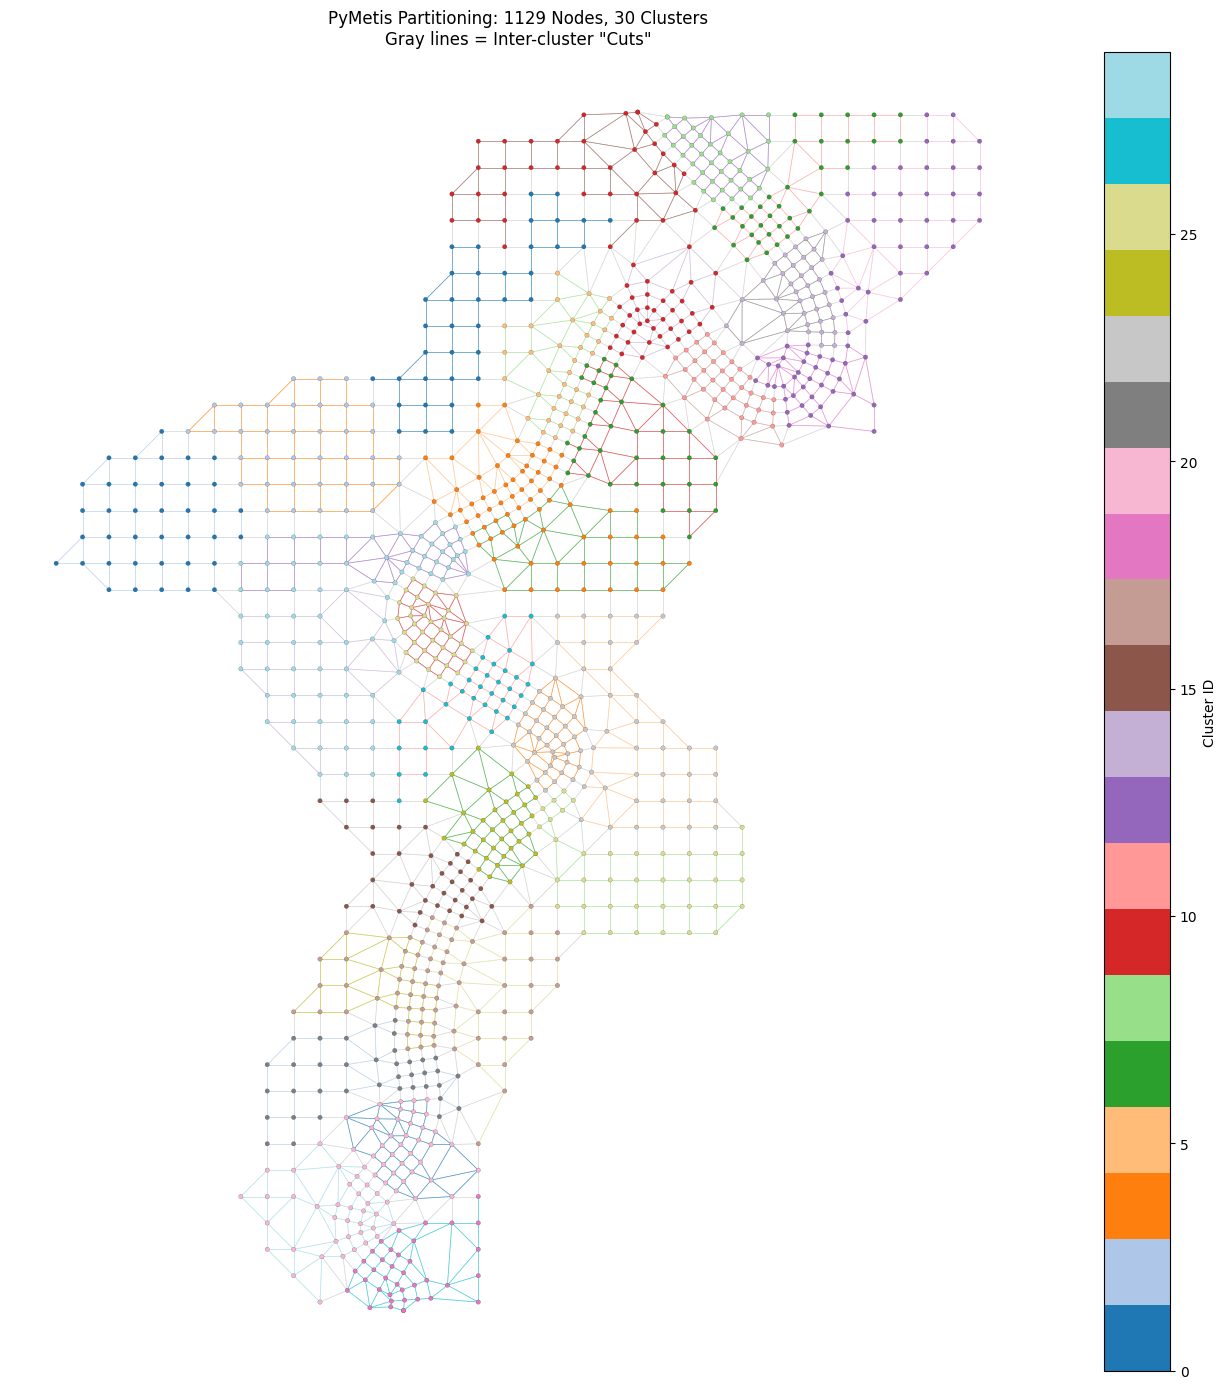

In [36]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

# 1. Prepare Edge Coordinates
# edge_index_undirected is (2, num_edges)
u_idx = edge_index_undirected[0].numpy()
v_idx = edge_index_undirected[1].numpy()

# Get start and end points for every edge
start_points = pos[u_idx]
end_points = pos[v_idx]

# Create a list of lines [[(x1, y1), (x2, y2)], ...]
lines = np.stack([start_points, end_points], axis=1)

# 2. Determine Edge Colors (Optional: Highlight Cuts)
edge_membership_u = np.array(membership)[u_idx]
edge_membership_v = np.array(membership)[v_idx]

# Edges where both nodes are in the same cluster get the cluster color
# Edges that connect different clusters (cuts) will be light gray
is_cut = edge_membership_u != edge_membership_v
line_colors = plt.cm.tab20(edge_membership_u % 20) # Match node colormap
line_colors[is_cut] = [0.8, 0.8, 0.8, 0.1] # Gray and very transparent for cuts

# 3. Final Plot
fig, ax = plt.subplots(figsize=(16, 14))

# Draw Edges first (LineCollection is very fast for large graphs)
lc = LineCollection(lines, colors=line_colors, linewidths=0.5, alpha=0.5)
ax.add_collection(lc)

# Draw Nodes on top
scatter = ax.scatter(
    pos[:, 0], pos[:, 1], 
    c=membership, 
    cmap='tab20', 
    s=10, 
    zorder=3, 
    alpha=1.0, 
    edgecolors='black', 
    linewidths=0.1
)

# Formatting
plt.colorbar(scatter, label='Cluster ID', ax=ax)
ax.set_title(f'PyMetis Partitioning: {num_nodes} Nodes, {n_clusters} Clusters\nGray lines = Inter-cluster "Cuts"')
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_axis_off() # Usually looks cleaner for large graphs
ax.set_aspect('equal')
plt.tight_layout()
plt.show()